# Notebook for Processing TR-XRD Data using the TRXRD Code

**Don't forget to update globals.py with detector information before running this code**

## Import Necessary Packages

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import trxrd


%matplotlib widget

## Define Experimental Parameters

In [ ]:
%%writefile globals.py 
# Experimental Parameters and Defaults

# ============================================================
# Data and Mask Paths, Scan Name, and Filename Pattern
# ============================================================
DATA_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3") # Path to directory containing TIFF files
MASK_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif") # Path to mask file
SCAN_NAME = "BTO400nmS3_360Kre4" # Prefix in file name to identify relevant files, e.g. "550nm_re" etc.
SCAN_TYPE = "delay_scan" # Type of scan based on filename pattern, e.g. "delay_scan", "theta_samz", etc. Must correspond to a key in the "filename_patterns" dictionary in trxrd.py
BACKGROUND_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BlankSubstratePinkBeam\blanksubstratePinkBeam285K-1.0fshw-4e-09delay00004_045.tif")
SAVE_PATH = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO400nmS3_360Kre4") # Path to directory where processed data will be saved, e.g. as .h5 file

# ============================================================
# General Defaults
# ============================================================
FIGSIZE = (10, 4)
STD_FACTOR = 3
MAX_PROCESSORS = 4
DELAY_SIGN = -1 # Check file naming scheme, sometimes positives delays have "-" in front and negative have no sign so need to invert sign

# ============================================================
# Beam Stop Mask Defaults
# ============================================================
MASK_CENTER_X = 52
MASK_CENTER_Y = 1667
MASK_RADIUS = 30

# ============================================================
# Center Guess and Sampling Defaults
# ============================================================
CENTER_X = 44
CENTER_Y = 1666
DOWNSAMPLE = 2 # Downsample factor for center finding, e.g. 2 means use every other pixel, 4 means use every 4th pixel, etc.

# ============================================================
# Detector Parameters and Defaults
# ============================================================
# PONI file from pyFAI-calib2. Set to a Path to use PONI geometry;
# set to None to use the manual parameters below.
PONI_FILE = None                 # Path to .poni file, or None
# Detector and beam parameters
PIXEL1 = 1.72e-4                 # m, detector pixel size along rows (y)
PIXEL2 = 1.72e-4                 # m, detector pixel size along cols (x)
DISTANCE = 0.1723                 # m, sample-to-detector distance
WAVELENGTH = 0.39738514824147314e-10          # m

# Detector orientation
TILT_ANGLE = np.deg2rad(0)               # rad
TILT_PLANE_ROTATION = np.deg2rad(90)      # rad
ROT3 = 0.0                      # rad, in-plane detector rotation

# Optional corrections
POLARIZATION_FACTOR = 0.999      # e.g. 0.99 or None
DARK = None                     # 2D dark image or None
FLAT = None                     # 2D flat-field image or None

# ============================================================
# Azimuthal Averaging and Normalization Defaults
# ============================================================
UNIT = "q_A^-1" # Unit for x-axis of azimuthally averaged data, e.g. "q_A^-1" for inverse Angstroms, "2theta_deg" for degrees, etc. 
NAN_MIN = 0.35 # Minimum value for valid data, values below this will be set to NaN, e.g. 0.35 or None for no minimum threshold
NAN_MAX = None # Maximum value for valid data, values above this will be set to NaN, e.g. 1.0 or None for no maximum threshold
NORM_MIN = 4.05 # Minimum value for normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
NORM_MAX = 4.25 # Maximum value for normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold
N_POINTS = 3000 # Number of points for azimuthal averaging, e.g. 3000 or None to use all pixels

# ============================================================
# Background Subtraction Defaults
# ============================================================
BACKGROUND_NORM_MIN = 1.0 # Minimum value for background normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
BACKGROUND_NORM_MAX = 1.5 # Maximum value for background normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold

# ============================================================
# Baseline Subtraction Defaults
# ============================================================
LAM_VAL = 1e4
P_VAL = 0.05

# ============================================================
# PDF Calcuation Defaults
# ============================================================
COMPOSITION = "WO3" # Sample composition for form factor calculation, e.g. "BaTiO3" or None for no form factor correction
R_MAX = 20.0 # Maximum r value for PDF calculation, e.g. 20.0 or None for no maximum
N_R = 2000 # Number of r points for PDF calculation, e.g.
Q_MIN = 0.5 # Minimum q value for PDF calculation, e.g. 0.5 or None for no minimum
Q_MAX = 15.0 # Maximum q value for PDF calculation, e.g. 16.0 or None for no maximum
WINDOW = "lorch" # Window function for PDF calculation, e.g. "lorch", "hanning", "blackman", or None for no window
# ============================================================
# Optional Saving .dat Files
# ============================================================
SAVE_AZAV_DAT = True # Whether to save azimuthally averaged profiles as .dat files in addition to the .h5 file, e.g. True or False
# ============================================================
# Form Factor CSV File
# ============================================================
FORM_FACTOR_FILE = Path(
    r"C:\Users\lheald\Documents\Guzelturk_Lab\gued\packages\x_ray_ff\atomic_FF_coeffs_clean.csv"
)

Overwriting globals.py


## Define File Paths

In [2]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}*.tif"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

# Detector mask file
mask_file = MASK_FILE
print(f"Using mask file: {mask_file}")

884 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3.
Using mask file: C:\Users\lheald\Box\TRXRDPython\testdata\mask_2021_dec.tif


## Import Images

884 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3 with scan name BTO400nmS3_240Ksurv3.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:226: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(test + 1), cmap="jet")


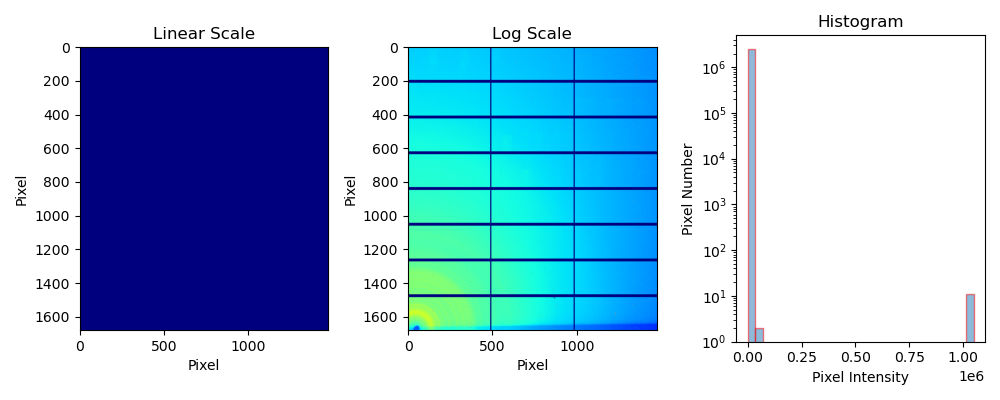

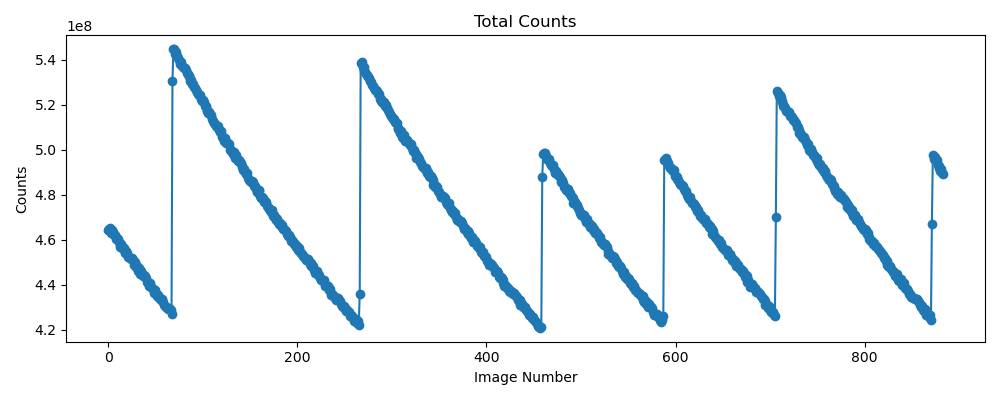

dict_keys(['images', 'sample_name', 'fluence', 'delay', 'image_number', 'counts', 'file_names'])
Images shape: (884, 1679, 1475)
Counts shape: (884,)
Unique delays: [-8.e-08 -5.e-09  6.e-10]


In [3]:
data_dict = trxrd.get_image_details(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,   
    sort=True,
    filter_data=False,
    plot=True,
)

print(data_dict.keys())
print("Images shape:", data_dict["images"].shape)
print("Counts shape:", data_dict["counts"].shape)
print("Unique delays:", np.unique(data_dict["delay"]))

## Remove Images Based on Total Counts

0 images removed from 884 initial images


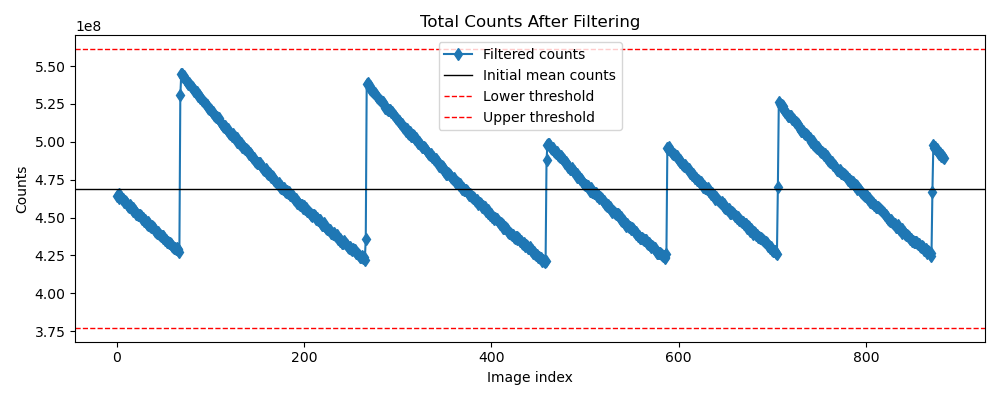

Clean images shape: (884, 1679, 1475)
Removed images: 0


In [4]:
count_result = trxrd.remove_counts(
    data_dict,
    std_factor=STD_FACTOR,
    added_range=None,   # e.g. [[10, 20]]
    plot=True,
    return_dict=True,
)

data_dict = count_result["filtered_data"]

print("Clean images shape:", data_dict["images"].shape)
print("Removed images:", count_result["n_removed"])

## Average by Delay

In [5]:
delay_avg_result = trxrd.average_images_by_delay(
    data_dict,
    return_dict=True,
)

data_dict = delay_avg_result
print("Averaged images shape:", data_dict["images"].shape)
print(data_dict.keys())

Averaged images shape: (3, 1679, 1475)
dict_keys(['images', 'std_images', 'delay', 'counts_per_delay', 'indices_by_delay', 'grouped_file_names', 'grouped_image_numbers'])


## Build Combined Masks

In [ ]:
image_shape = data_dict["images"].shape[1:]   # (rows, cols)

combined_mask = trxrd.build_combined_mask(
    image_shape=image_shape,
    center_xy=(MASK_CENTER_X, MASK_CENTER_Y),
    radius=MASK_RADIUS,
    mask_path=MASK_FILE,
)

print("Combined mask shape:", combined_mask.shape)

Combined mask shape: (1679, 1475)


## Remove Hot Pixels

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:1332: RuntimeWarning: Mean of empty slice
  mean_image = np.nanmean(image_stack, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Removing hot pixels from 3 image(s)...
  Completed 3/3 (100.0%)
Done removing hot pixels.


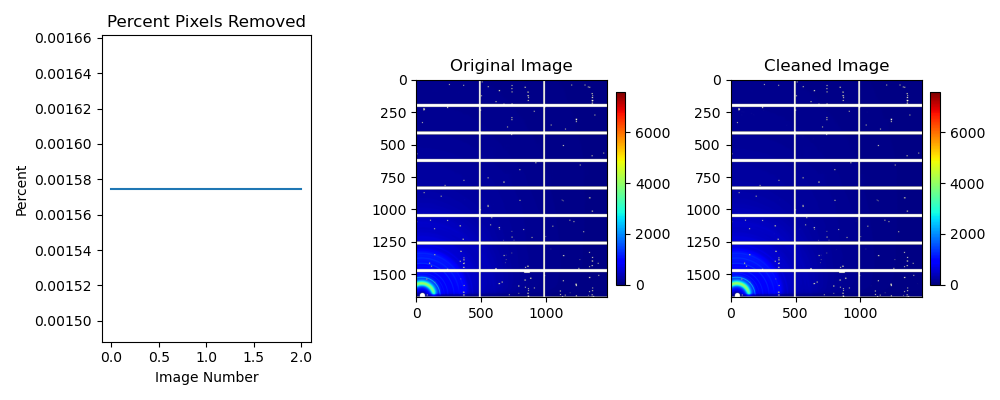

Mean percent pixels removed: 0.0015747872522990883
Max percent pixels removed: 0.0015747872522990885


In [ ]:
xr_result = trxrd.remove_xrays_pool(
    data_dict["images"],
    std_factor=STD_FACTOR,
    plot=True,
    image_index=0,
    return_dict=True,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
    mask_bool=combined_mask
)

data_dict["images"] = xr_result["clean_data"]

print("Mean percent pixels removed:", np.nanmean(xr_result["pct_removed"]))
print("Max percent pixels removed:", np.nanmax(xr_result["pct_removed"]))

## Find Centers for Images

Finding centers for 3 images...
  Completed 3/3 (100.0%)
Done finding centers.


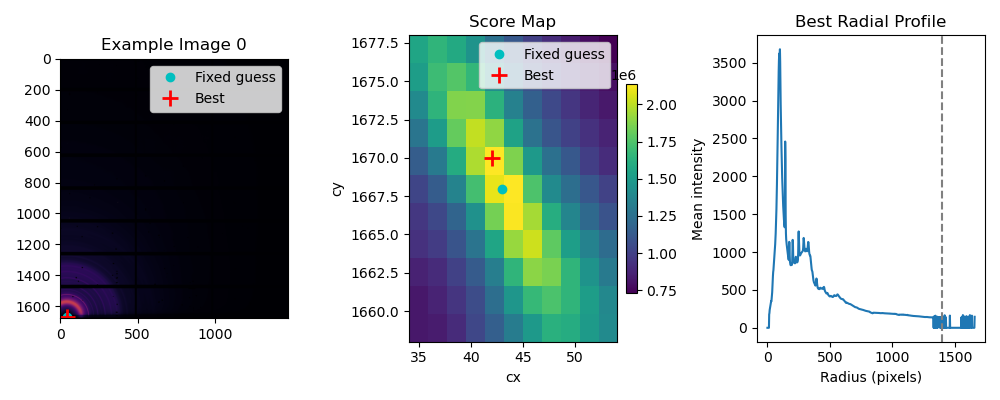

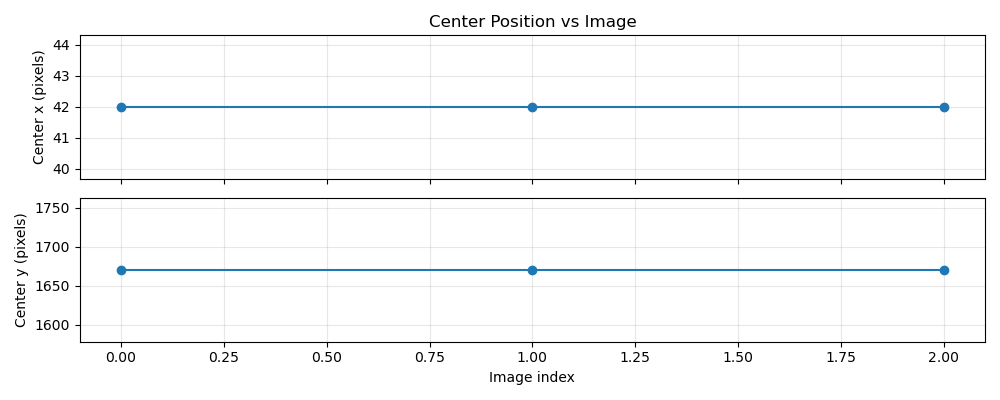

Centers shape: (3, 2)
First center: [  42. 1670.]
Mean center: [  42. 1670.]


In [ ]:
center_result = trxrd.find_centers_in_stack_radial_parallel(
    data_array=data_dict["images"],
    center_guess_yx=(CENTER_Y, CENTER_X),   # note: (y, x)
    search_radius=20,
    center_mask=None,
    r_min=0,
    r_max=1400,
    downsample=2,
    intensity_threshold=None,
    top_percentile=60,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
    plot_example=True,
    example_index=0,
    plot_center_vs_image=True,
)

centers = center_result["centers_xy"]
print("Centers shape:", centers.shape)
print("First center:", centers[0])
mean_center = np.mean(centers, axis=0)
print(f"Mean center: {mean_center}")


## Compute Azimuthal Average

Integrating 3 images...
  Completed 3/3 (100.0%)
Done integrating.
q shape: (5000,)
profiles shape: (3, 5000)


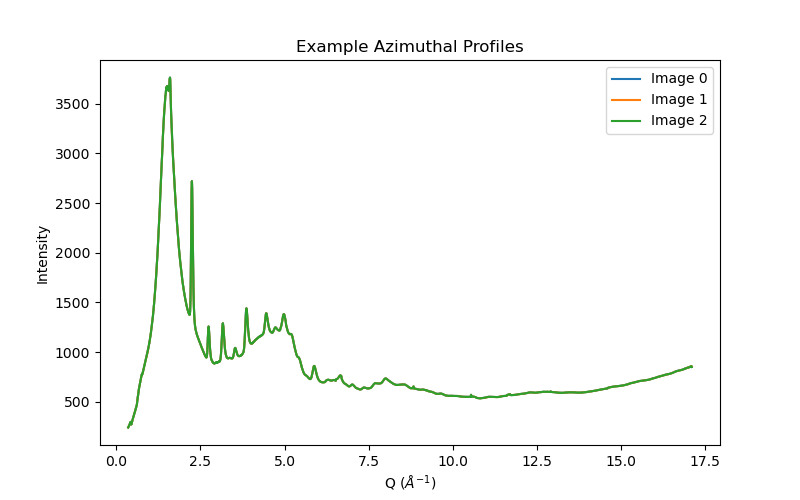

In [ ]:
az_result = trxrd.azimuthal_average_pyfai(
    images=data_dict["images"],
    centers_xy=mean_center,
    npt=5000,
    unit=UNIT,
    integration_mask=combined_mask,
    nan_radial_range=(NAN_MIN, NAN_MAX),   # set Q < 0.3 to NaN
    azimuth_range=None,
    integration_mask=None,
    return_dict=True,
    progress_interval=100,
)

q = az_result["radial"]
profiles = az_result["profiles"]

print("q shape:", q.shape)
print("profiles shape:", profiles.shape)

plt.figure(figsize=(8, 5))
for i in [0, 1, 2]:
    plt.plot(q, profiles[i], label=f"Image {i}")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Intensity")
plt.title("Example Azimuthal Profiles")
plt.legend()
plt.show()

## Normalize Azimuthal Averages

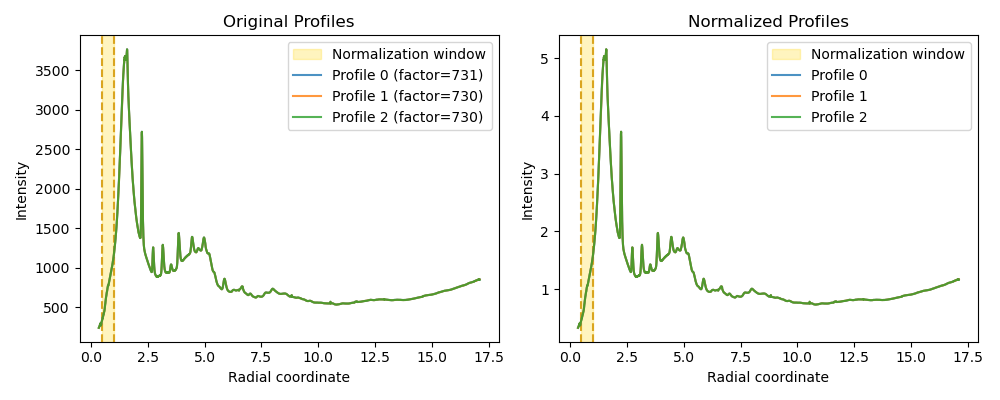

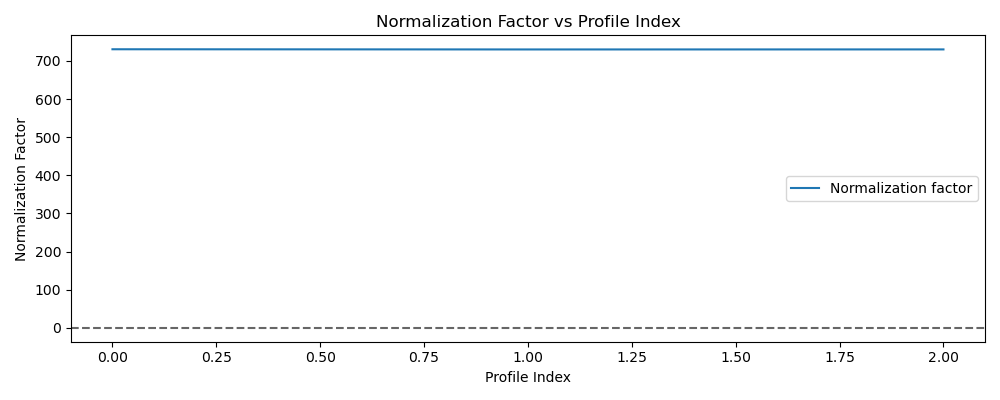

In [ ]:
norm_result = trxrd.normalize_profiles_to_range(
    radial=q,
    profiles=profiles,
    norm_range=(NORM_MIN, NORM_MAX),   # example
    mode="mean",
    plot=True,
    plot_indices=[0, 1, 2],
    show_normalized_plot=True,
    return_dict=True,
    plot_factors=True,
)

profiles_norm = norm_result["normalized_profiles"]

## Load and Prepare Background Image(s)

dict_keys(['files', 'background_stack', 'background_mean', 'background_std', 'n_images'])
Background stack shape: (1, 1679, 1475)
Background mean shape: (1679, 1475)
Integrating 1 images...


C:\Users\lheald\AppData\Local\Temp\ipykernel_34852\2878563893.py:21: RuntimeWarning: Mean of empty slice
  bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


  Completed 1/1 (100.0%)
Done integrating.


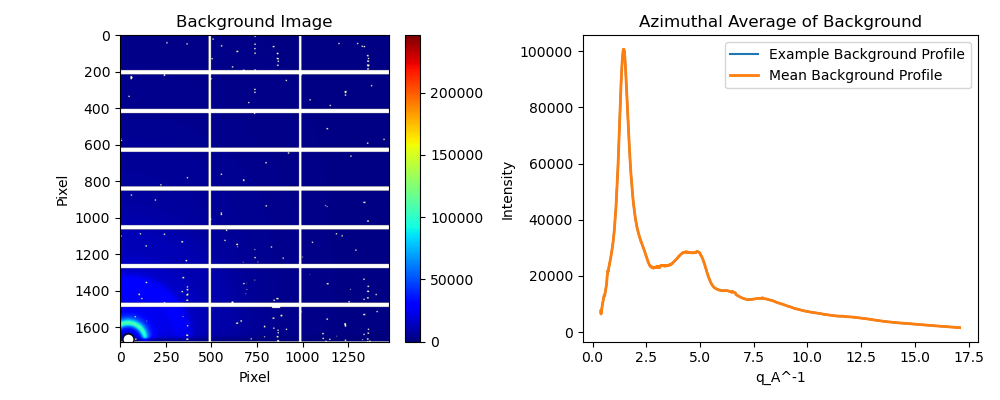

In [ ]:
# Background path can be either:
# - a single tif file
# - or a folder containing many background tif files
# Load Data
bg_dict = trxrd.load_background(
    background_path=BACKGROUND_PATH,
    sort=True,
    plot=False,
)

print(bg_dict.keys())
print("Background stack shape:", bg_dict["background_stack"].shape)
print("Background mean shape:", bg_dict["background_mean"].shape)

bg_dict["background_stack"] = trxrd.apply_mask_from_bool(
    data_array=bg_dict["background_stack"],
    mask_bool=combined_mask,
)


bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


# Compute background azimuthal average
bg_az_result = trxrd.compute_background_azimuthal_average(
    background_input=bg_dict["background_stack"],
    centers_xy=(CENTER_X, CENTER_Y),   # one average center in (x, y)
    unit=UNIT,
    polarization_factor=POLARIZATION_FACTOR,
    npt=N_POINTS,
    use_custom_polarization=False,
    integration_function="integrate1d",
    correct_solid_angle=False,
    plot=True,
)

q_bg = bg_az_result["radial"]
background_profile = bg_az_result["background_profile_mean"]



## Subtract Scaled Background from Images

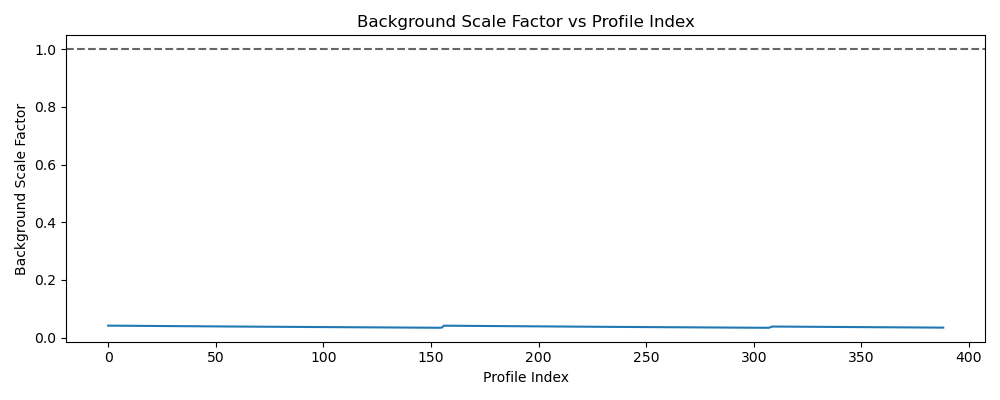

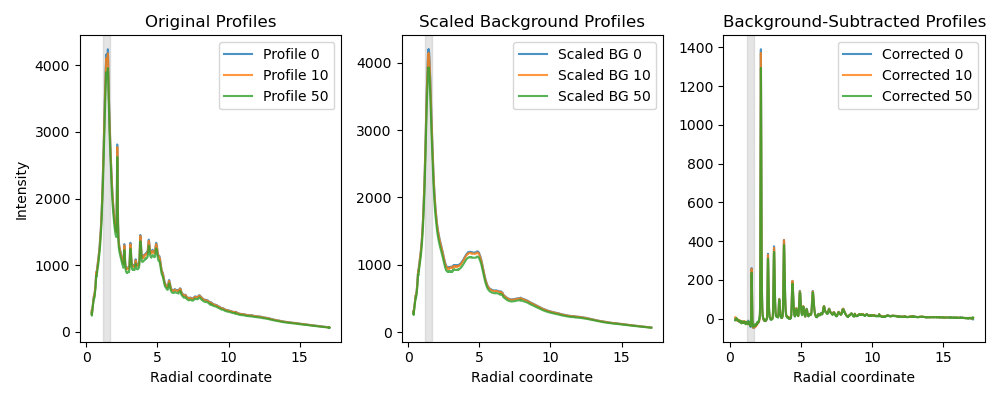

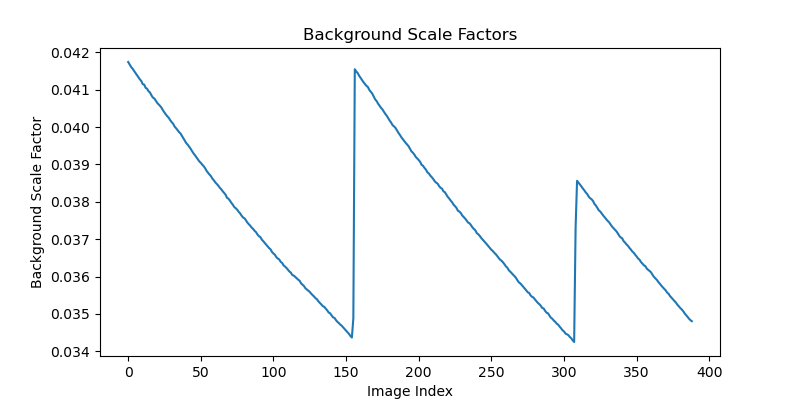

In [ ]:
bgsub_result = trxrd.subtract_scaled_background_profile(
    radial=q,
    profiles=profiles,
    background_profile=background_profile,
    norm_range=(1.2, 1.7),   # example region; adjust as needed
    mode="mean",
    scale_method="ratio",
    plot=True,
    plot_scale_factors=True,
    plot_indices=[0, 10, 50],
    return_dict=True,
)

profiles_bgsub = bgsub_result["corrected_profiles"]
baselines = bgsub_result["scaled_background_profiles"]

# Inspect Scaling Factors
plt.figure(figsize=(8, 4))
plt.plot(bgsub_result["scale_factors"])
plt.xlabel("Image Index")
plt.ylabel("Background Scale Factor")
plt.title("Background Scale Factors")
plt.show()

## Subtract Baseline from Images

c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\scipy\sparse\_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


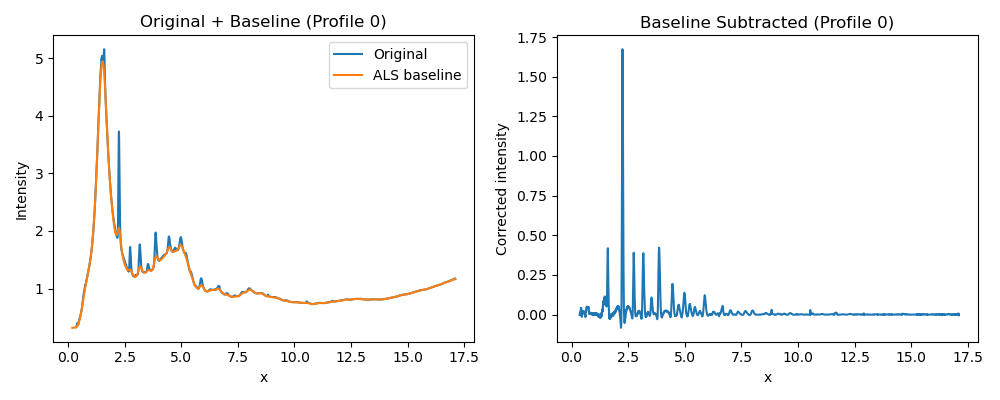

In [13]:
als_result = trxrd.subtract_als_baseline(
    data_array=profiles_norm,
    x_vals=q,
    lam=LAM_VAL,
    p=P_VAL,
    niter=10,
    plot=True,
    return_dict=True,
)

profiles_flat = als_result["corrected_data"]
baselines = als_result["baselines"]


## Make Reference Profile

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:3626: RuntimeWarning: Mean of empty slice
  reference_profile = np.nanmean(ref_group, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


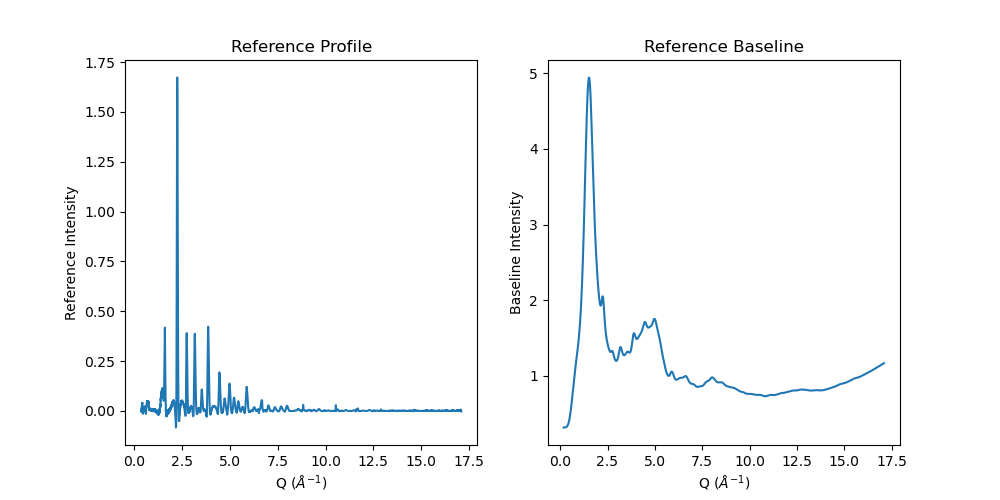

In [14]:
ref_result = trxrd.make_reference_profile(
    profiles=profiles_flat,
    delays=data_dict["delay"],
    reference_selector=None,
    return_dict=True,
)

ref_baseline = trxrd.make_reference_profile(
    profiles=baselines,
    delays=data_dict["delay"],
    reference_selector=None,
    return_dict=True,
)

reference_profile = ref_result["reference_profile"]
reference_baseline = ref_baseline["reference_profile"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q, reference_profile)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Reference Intensity")
plt.title("Reference Profile")

plt.subplot(1, 2, 2)
plt.plot(q, reference_baseline)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Baseline Intensity")
plt.title("Reference Baseline")

plt.show()

## Compute Difference Profiles

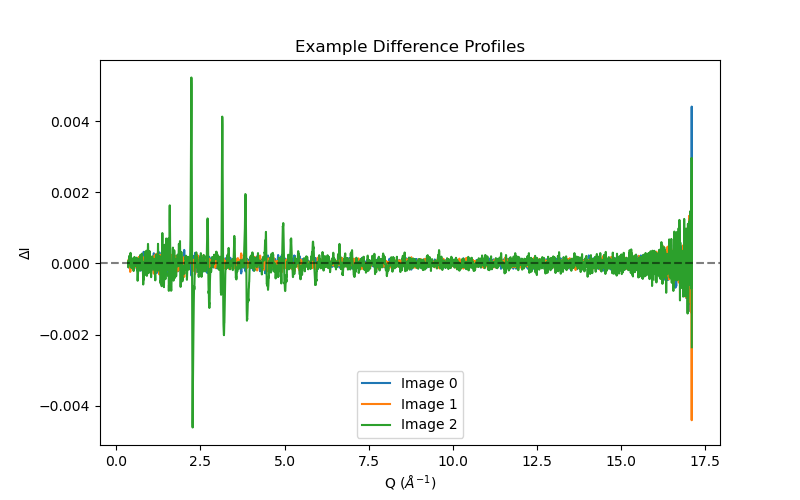

In [15]:
delta_result = trxrd.compute_delta_profiles(
    profiles=profiles_flat,
    reference_profile=reference_profile,
    mode="subtract",
    return_dict=True,
)

baseline_results = trxrd.compute_delta_profiles(
    profiles=baselines,
    reference_profile=reference_baseline,
    mode="subtract",
    return_dict=True,
)

delta_profiles = delta_result["delta_profiles"]
delta_baselines = baseline_results["delta_profiles"]


# Plot example difference profiles
plt.figure(figsize=(8, 5))
for i in [0, 1, 2]:
    plt.plot(q, delta_profiles[i], label=f"Image {i}")
plt.axhline(0, color="k", linestyle="--", alpha=0.5)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("ΔI")
plt.title("Example Difference Profiles")
plt.legend()
plt.show()

## Average by Delay

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:3550: RuntimeWarning: Mean of empty slice
  mean_profiles[i] = np.nanmean(group, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


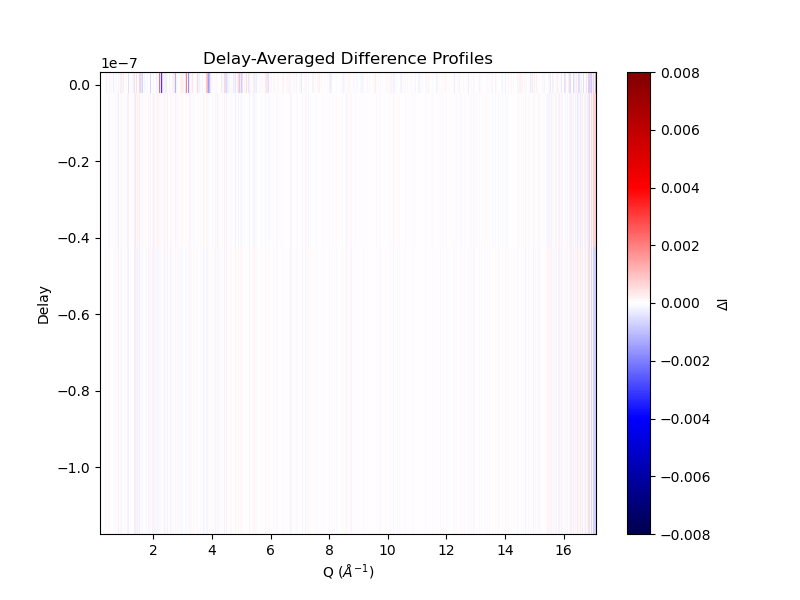

In [19]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_profiles,
    delays=data_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_profiles = delay_result["mean_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(q, unique_delays, mean_profiles, shading="auto", cmap="seismic")
plt.colorbar(label="ΔI")
#plt.ylim(-2e-8, 1e-8)
plt.clim(-0.008, 0.008)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Plot Lineouts 

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:3734: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=figsize)


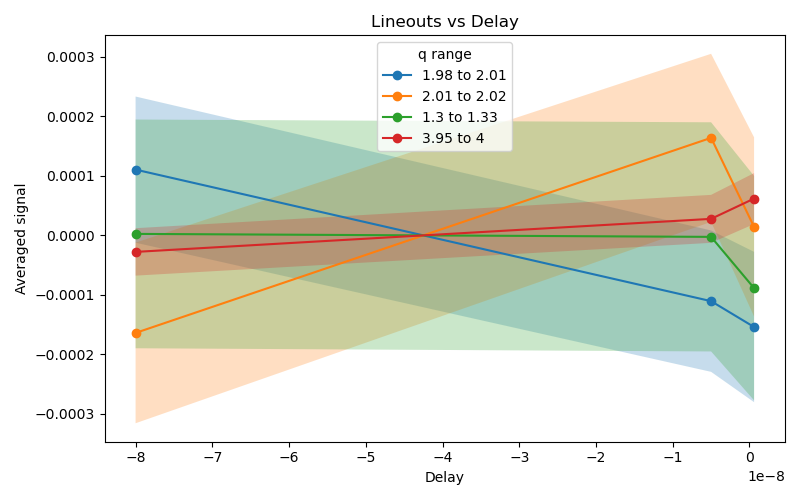

In [19]:
lineout_result = trxrd.lineouts_by_delay_from_per_image_profiles(
    radial=q,
    delta_profiles=delta_profiles,
    delays=data_dict["delay"],
    q_ranges=[(1.98, 2.01), (2.01, 2.025), (1.3, 1.33), (3.95, 4.0)],
    average_mode="mean",
    error_type="sem",
    plot=True,
    return_dict=True,
)

## Check Baseline per Delay

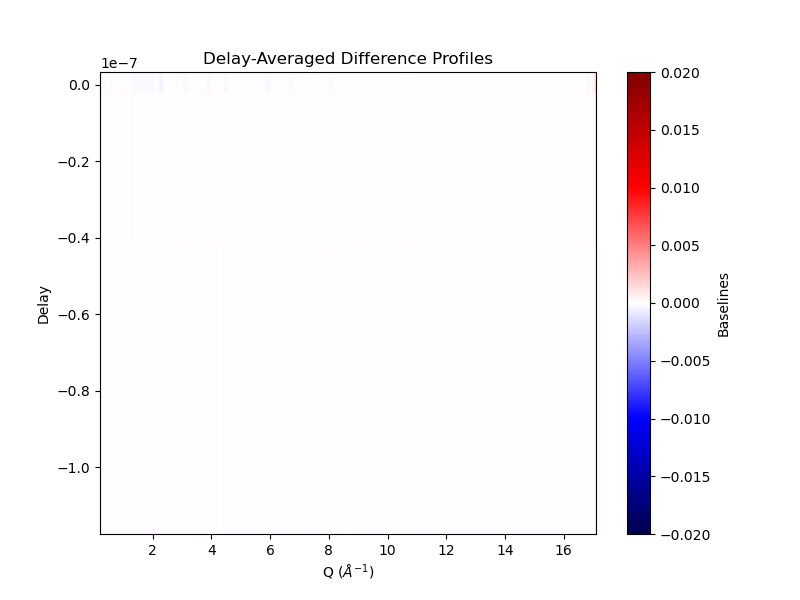

In [20]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_baselines,
    delays=data_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_bkgs = delay_result["mean_profiles"]
std_bkgs = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(q, unique_delays, mean_bkgs, shading="auto", cmap="seismic")
plt.colorbar(label="Baselines")
plt.clim(-0.02, 0.02)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Calculate f and f(2)

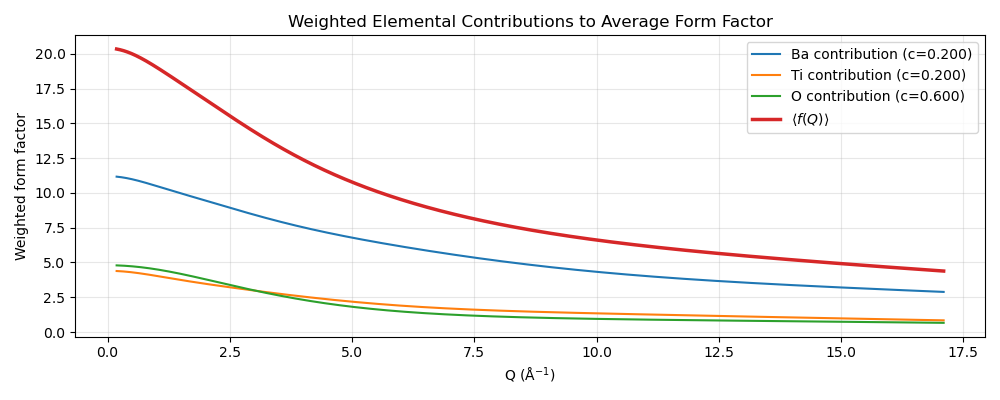

In [20]:
ff_results = trxrd.compute_average_form_factors(q, "BaTiO3", plot=True)

f_avg = ff_results["f_avg"]
f2_avg = ff_results["f2_avg"]


## Calculate S(Q) and F(Q)

In [21]:
# sq_result = trxrd.normalize_xray_scattering_to_sq_fq(
#     q=q,
#     iq=iq_total,
#     composition="BaTiO3",
#     mode="total",
#     plot=True,
#     return_dict=True,
# )

# sq = sq_result["sq"]
# fq = sq_result["fq"]

## Calculate dS(Q) and dF(Q)

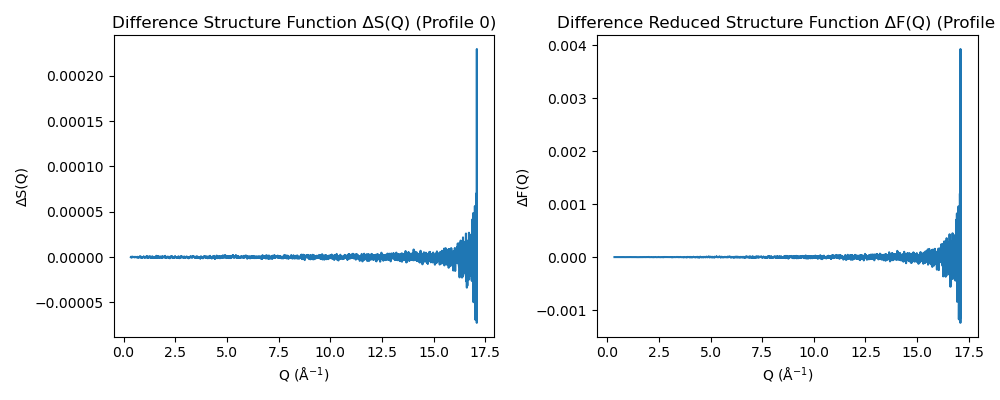

In [22]:
delta_result = trxrd.normalize_xray_scattering_to_sq_fq(
    q=q,
    iq=delta_profiles,
    composition="BaTiO3",
    mode="difference",
    plot=True,
    profile_index=0,
    return_dict=True,
)

delta_sq = delta_result["delta_sq"]
delta_fq = delta_result["delta_fq"]

## Calculate dG(r)

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:4883: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=figsize)


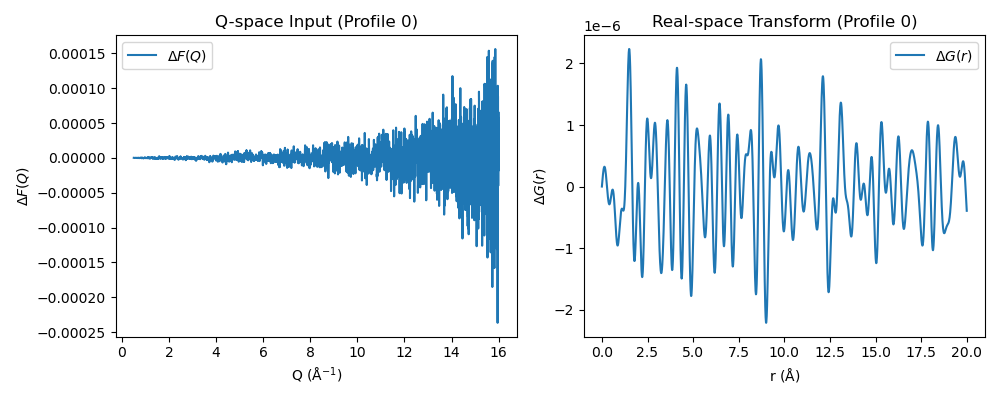

(3, 2000)


In [23]:
dGr_result = trxrd.compute_delta_gr_from_delta_fq(
    q=q,
    delta_fq=delta_result["delta_fq"],
    r_max=R_MAX,
    n_r=N_R,
    q_range=(Q_MIN, Q_MAX),
    window=WINDOW,
    plot=True,
    profile_index=0,
    return_dict=True,
)

r = dGr_result["r"]
dGr_profiles = dGr_result["delta_gr"]
print(dGr_profiles.shape)   # should be (n_profiles, n_r)

## Plot Delay Averaged dG(r)

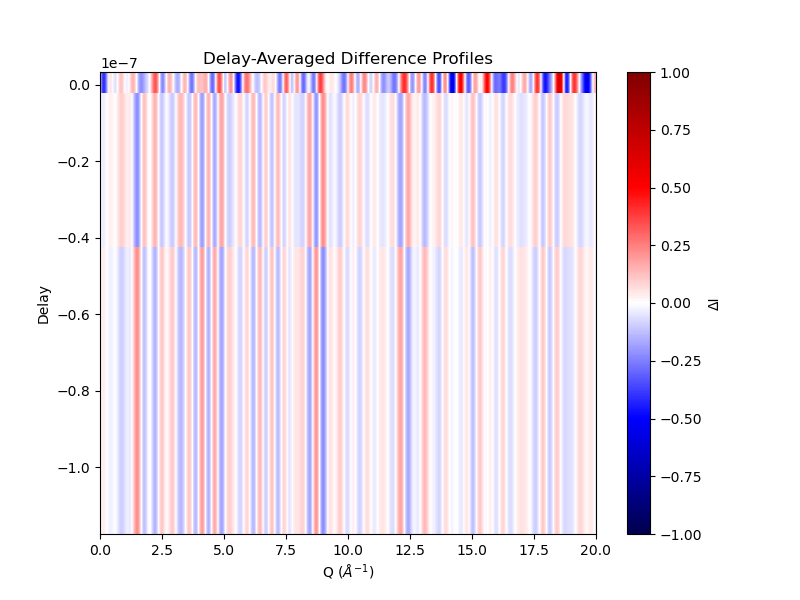

In [24]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=dGr_profiles,
    delays=data_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_dgrs = delay_result["mean_profiles"]
std_dgrs = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(r, unique_delays, mean_dgrs*1e5, shading="auto", cmap="seismic")
plt.colorbar(label="ΔI")
plt.clim(-1, 1)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Compare Results

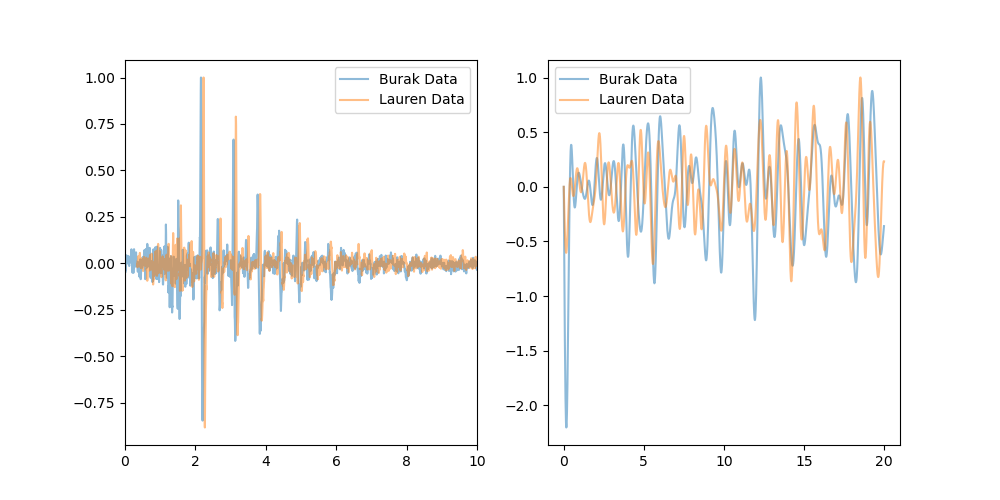

In [25]:
df = pd.read_excel("C:\\Users\\lheald\\Documents\\Guzelturk_Lab\\TRXRDPython\\testdata\\output\\BaTiO3_data_CottsExp_Nov25.xlsx", header=2)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(df["Q"], df["deltaI(Q,0.6ns)"]/np.nanmax(df["deltaI(Q,0.6ns)"]), alpha=0.5, label="Burak Data")
plt.plot(q, mean_profiles[2]/np.nanmax(mean_profiles[2]), alpha=0.5, label="Lauren Data")
plt.xlim(0,10)
plt.legend()

plt.subplot(1,2,2)
plt.plot(df["r"], df["deltaG(r,0.6ns)"]/np.nanmax(df["deltaG(r,0.6ns)"]), alpha=0.5, label="Burak Data")
plt.plot(r, dGr_profiles[2]/np.nanmax(dGr_profiles[2]), alpha=0.5, label="Lauren Data")
plt.legend()
plt.show()

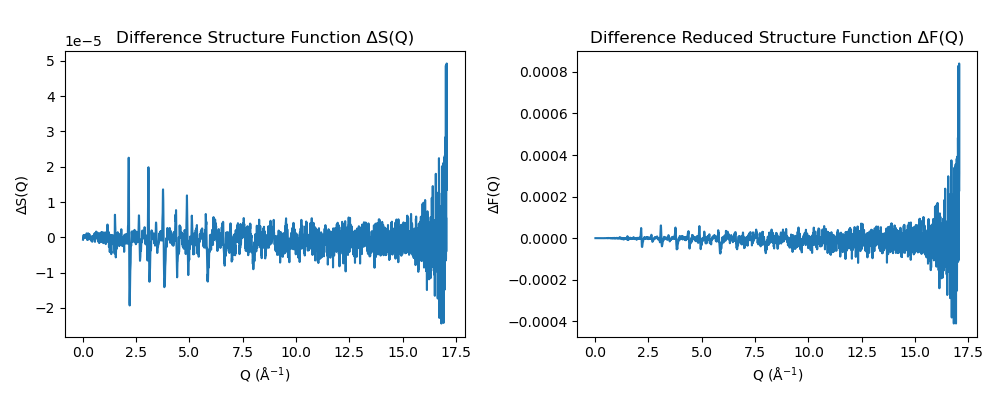

dict_keys(['q', 'delta_sq', 'delta_fq', 'f_avg', 'f2_avg', 'composition_dict', 'atomic_fractions', 'input_was_1d', 'mode'])


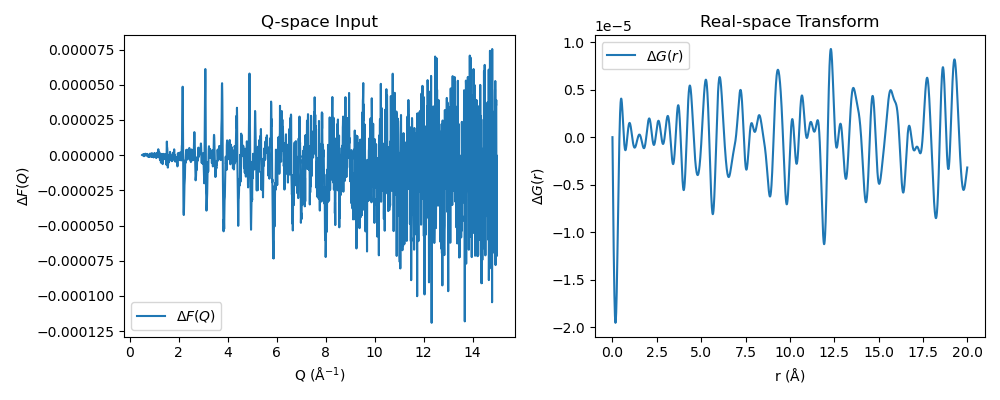

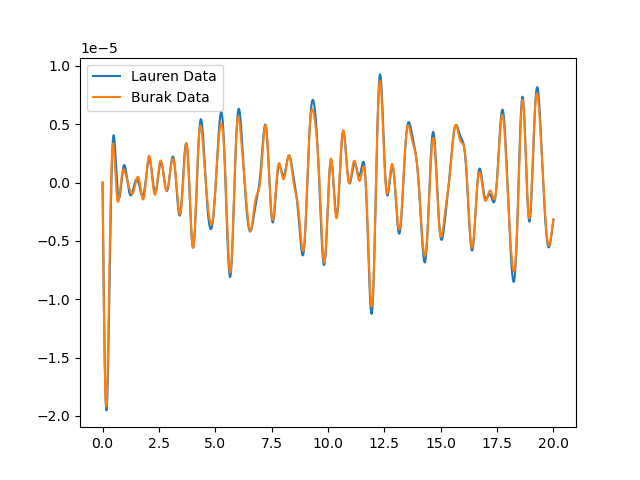

In [57]:
temp_dict = trxrd.normalize_xray_scattering_to_sq_fq(
    q=df["Q"],
    iq=df["deltaI(Q,0.6ns)"], 
    composition="BaTiO3",
    mode="difference",
    plot=True,
    return_dict=True,
)

print(temp_dict.keys())

temp_gr_result = trxrd.compute_delta_gr_from_delta_fq(
    q=df["Q"],
    delta_fq=temp_dict["delta_fq"],
    r_max=20,
    n_r=2000,
    q_range=(0.5, 15),
    window="lorch",
    plot=True,
    profile_index=0,
    return_dict=True,
)

plt.figure()
plt.plot(temp_gr_result["r"], temp_gr_result["delta_gr"], label="Lauren Data")
plt.plot(df["r"], df["deltaG(r,0.6ns)"]*2, label="Burak Data")
plt.legend()
plt.show()

## Save Results

In [ ]:
# np.savez(
#     "trxrd_processed_results.npz",
#     q=q,
#     delays=clean_dict["delay"],
#     image_numbers=clean_dict["image_number"],
#     centers=centers,
#     profiles=profiles,
#     profiles_bgsub=profiles_bgsub,
#     profiles_norm=profiles_norm,
#     reference_profile=reference_profile,
#     delta_profiles=delta_profiles,
#     unique_delays=unique_delays,
#     mean_profiles=mean_profiles,
#     std_profiles=std_profiles,
# )

: 

## Calculate Qualitative dPDF

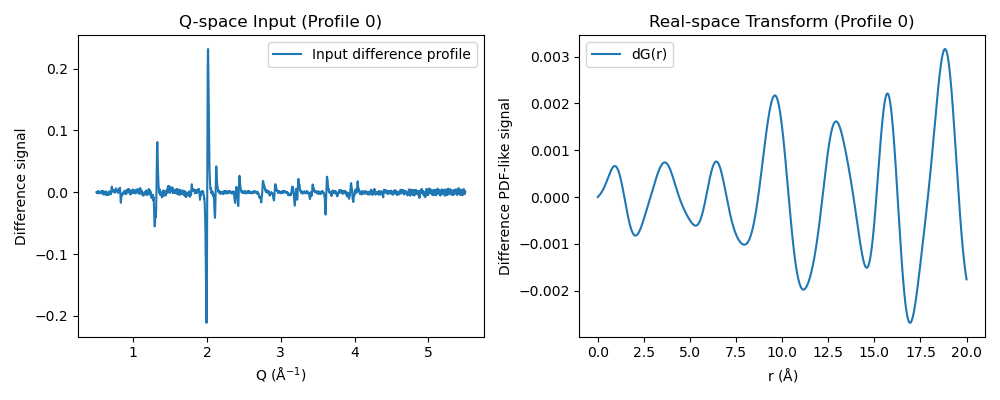

(122, 2000)


In [ ]:
dgr_result = trxrd.compute_difference_pdf(
    q=q,
    delta_iq=delta_profiles,
    r_max=20,
    n_r=2000,
    q_range=(0.5, 5.5),
    window="lorch",
    plot=True,
    profile_index=0,
    return_dict=True,
)

r = dgr_result["r"]
dgr_profiles = dgr_result["dgr"]
print(dgr_profiles.shape)   # should be (n_profiles, n_r)

## Plot Qualitative dPDF by Delay (no form factors)

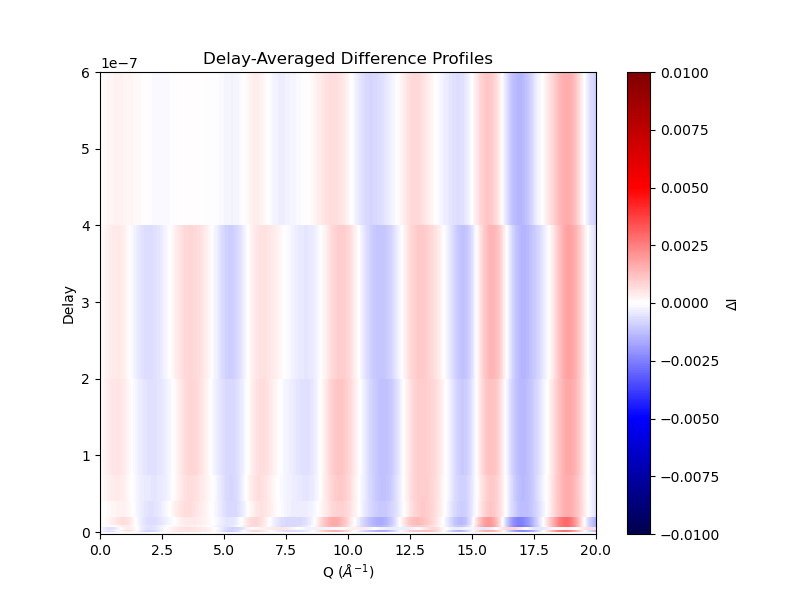

In [ ]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=dgr_profiles,
    delays=clean_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_dgrs = delay_result["mean_profiles"]
std_dgrs = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(r, unique_delays, mean_dgrs, shading="auto", cmap="seismic")
plt.colorbar(label="ΔI")
plt.clim(-0.01, 0.01)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()